In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

from System.system import System, Agent, Lag

In [3]:
def identity(arr):
    return arr

In [4]:
def make_skewsymm(n):
    motor_transform = np.ones((n,n)) 
    motor_transform[np.diag_indices(n)] = np.zeros(n)
    motor_transform[np.tril_indices(n)] = motor_transform[np.tril_indices(n)] * -1
    return motor_transform

## System_01 - Dual Agent (n=10)

In [334]:
n = 10
motor_transform = make_skewsymm(n)
# motor_transform = np.ones((n,n))
motor_transform

array([[-0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [-1., -0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [-1., -1., -0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [-1., -1., -1., -0.,  1.,  1.,  1.,  1.,  1.,  1.],
       [-1., -1., -1., -1., -0.,  1.,  1.,  1.,  1.,  1.],
       [-1., -1., -1., -1., -1., -0.,  1.,  1.,  1.,  1.],
       [-1., -1., -1., -1., -1., -1., -0.,  1.,  1.,  1.],
       [-1., -1., -1., -1., -1., -1., -1., -0.,  1.,  1.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -0.,  1.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1., -0.]])

In [335]:
er = np.linalg.eig(motor_transform)

In [336]:
np.round(er[0],1)

array([-0.+6.3j, -0.-6.3j,  0.+2.j ,  0.-2.j , -0.+1.j , -0.-1.j ,
       -0.+0.5j, -0.-0.5j, -0.+0.2j, -0.-0.2j])

In [626]:
np.random.seed(420)
# n = 10

l_val = 0.2

a_val = 0.8
a_val_pw = 0.8

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
# motor_transform = np.random.rand(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
# does not adjust reference
def feedback_false(error, reference, reference_init):
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init):
    mu = 0.000000010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        return reference_init
    else:
        return reference - (error * a_val_pw)

# SYSTEM INIT
sys_06a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# SYSTEM INIT
sys_06a2 = Agent(sense, compare, effect, move, feedback_piecewise,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (hybrid)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_06b = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (conformist)",
                verbose=True)

# SYSTEM INIT
sys_06c = Agent(sense, compare, effect, move, feedback_false,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (stubborn)",
                verbose=True)

# SYSTEM INIT
sys_06d = Agent(sense, compare, effect, move, feedback_piecewise,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.7),
                name="Agent_2 (hybrid)",
                verbose=True)

 # -------------------------------------- #

# LAG: Creates a buffered window for the last {max_lag} amount of timepoints
# and randomly chooses a values in that window; making so that the outputted
# datum is > 0 but < {max_lag} delayed.

max_lag = 5

sys_06l1 = Lag(n,max_lag=max_lag, random_mask=True)

sys_06l2 = Lag(n,max_lag=max_lag, random_mask=True)


 # -------------------------------------- #

# # TOTAL SYSTEM INIT
sys_06_total = System(np.random.rand(4,n),
                ((sys_06d, [3]), (sys_06a2, [2]), (sys_06l1, [0]), (sys_06l2, [1])),
                ["Agent_2 output", "Agent_1 output", "Lag_1 output", "Lag_2 output"],
               verbose=True)

# # # TOTAL SYSTEM INIT (UNCOMMENT TO REMOVE JITTERS)
# sys_06_total = System(np.random.rand(2,n),
#                 ((sys_06d, [1]), (sys_06a, [0])),
#                 ["Agent_1 input", "Agent_2 input"],
#                verbose=True)

sysout = sys_06_total.go(10000)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


In [627]:
sys_06_total.deep_channel_names()

['Agent_2 output',
 'Agent_1 output',
 'Lag_1 output',
 'Lag_2 output',
 'Agent_2 (hybrid) sense signal',
 'Agent_2 (hybrid) error signal',
 'Agent_2 (hybrid) effect signal (motor state)',
 'Agent_2 (hybrid) reference signal',
 'Agent_2 (hybrid) reference initial',
 'Agent_1 (hybrid) sense signal',
 'Agent_1 (hybrid) error signal',
 'Agent_1 (hybrid) effect signal (motor state)',
 'Agent_1 (hybrid) reference signal',
 'Agent_1 (hybrid) reference initial']

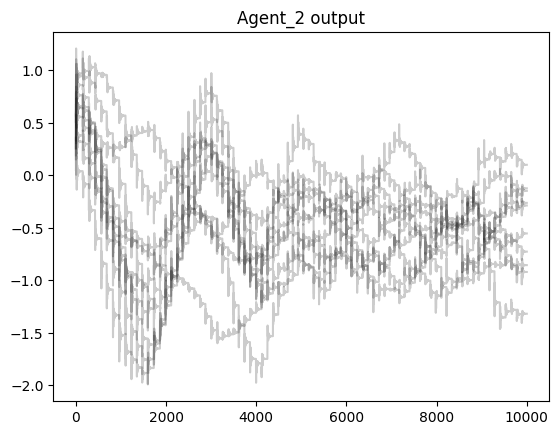

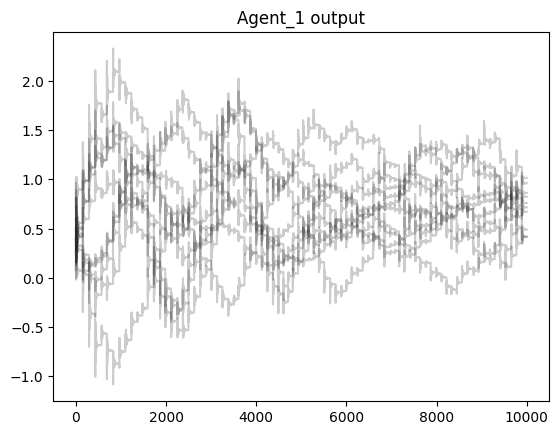

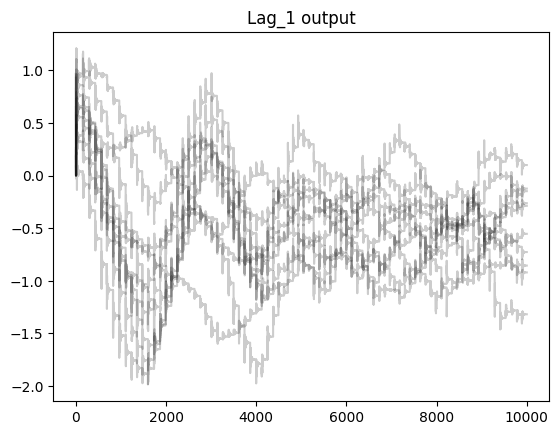

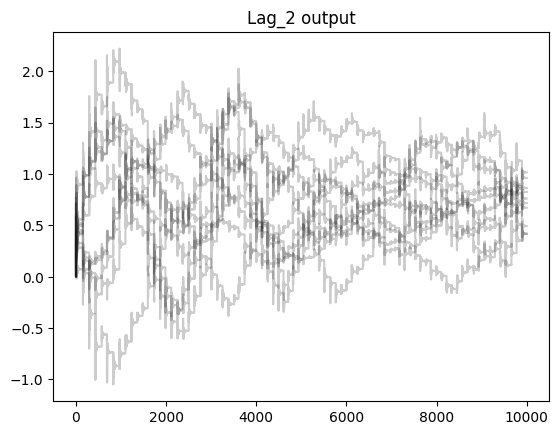

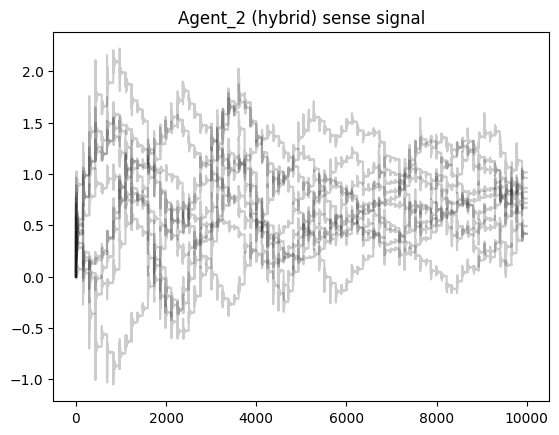

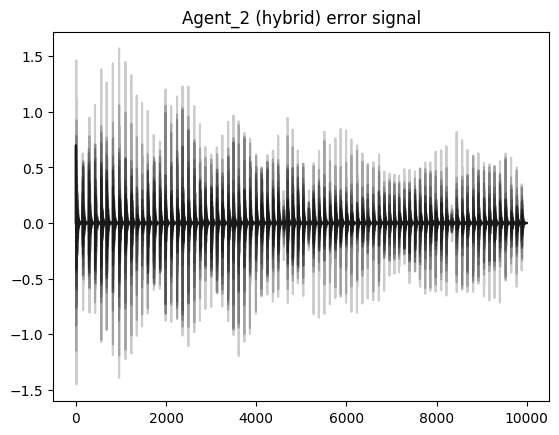

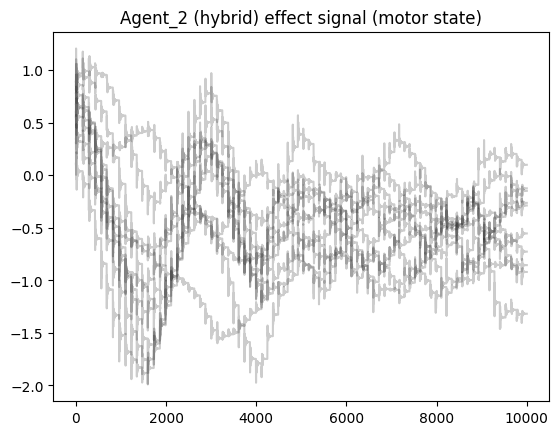

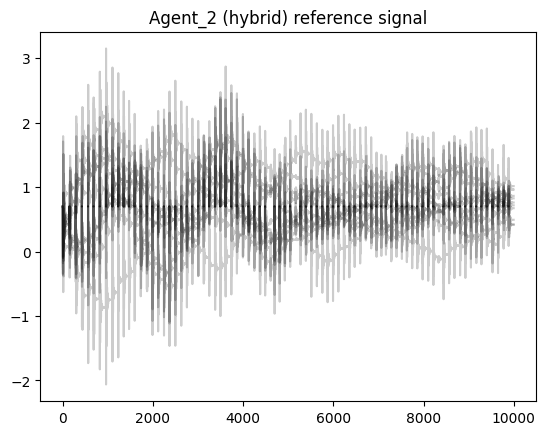

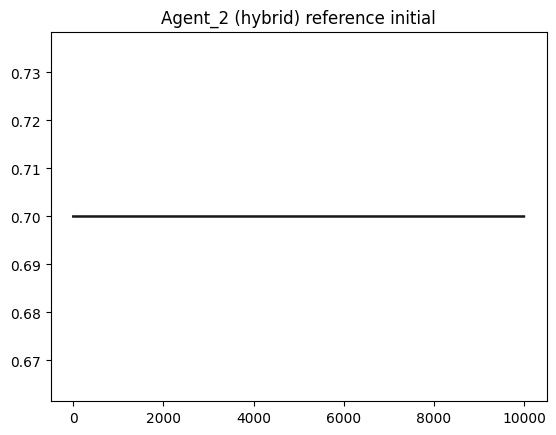

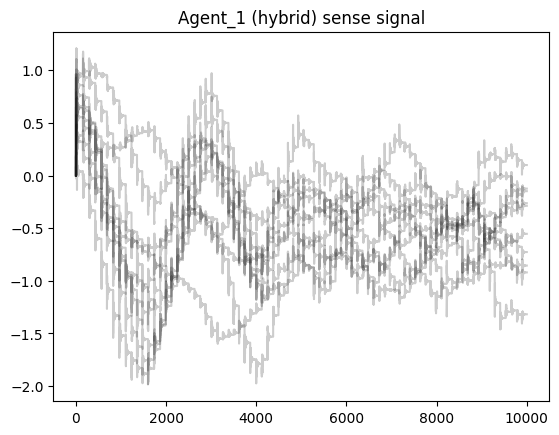

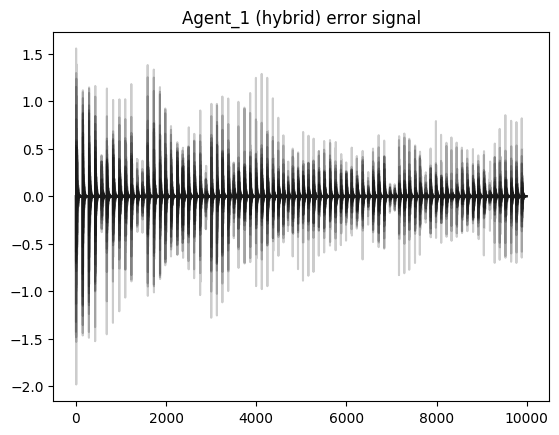

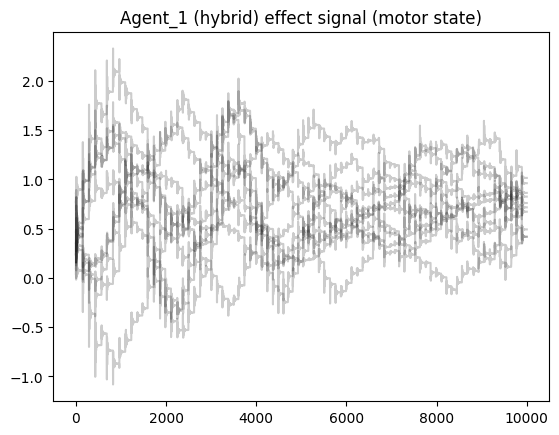

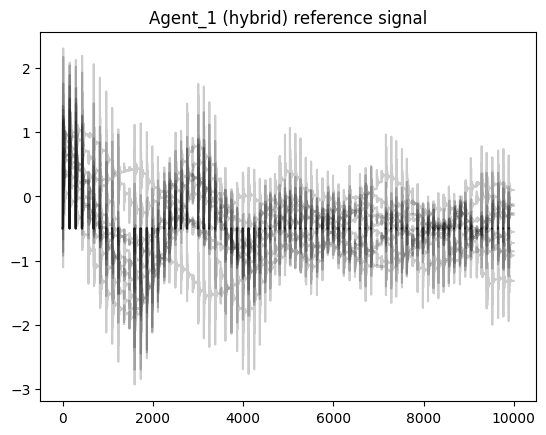

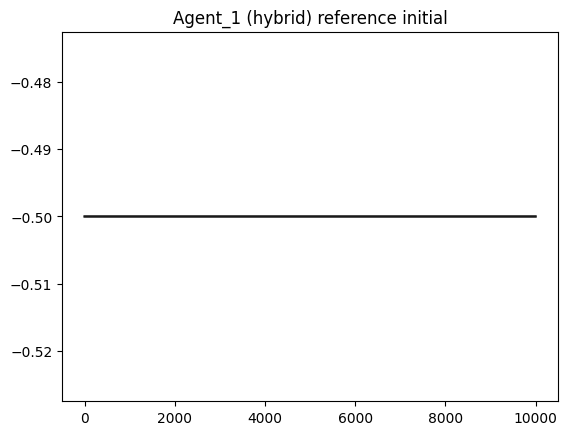

In [628]:
dcn = sys_06_total.deep_channel_names()
def plot_sysout(i):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

for i in range(sysout.shape[1]):
    plot_sysout(i)


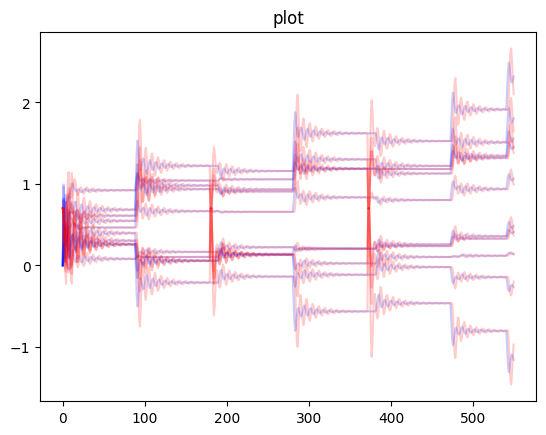

In [574]:
plt.plot(sysout[:550,4,:], 'b-', alpha=2/n)
plt.plot(sysout[:550,7,:], 'r-', alpha=2/n)
# plt.ylim(-0.1,0.1)
plt.title("plot")
plt.show()

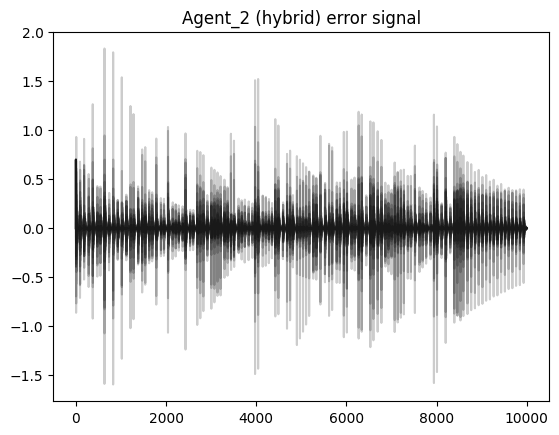

In [575]:
plot_sysout(5)

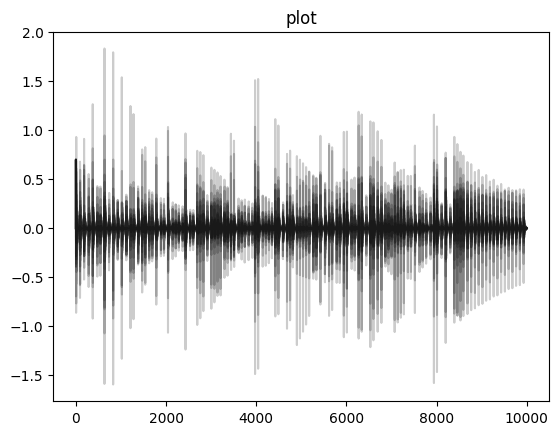

In [576]:
plt.plot(sysout[:40000,5,:], 'k-', alpha=2/n)
# plt.ylim(-0.1,0.1)
plt.title("plot")
plt.show()

In [580]:
sd.play(sysout[:,5,1], 1000)

# OLD Code (for reference)